# Task 5 — Sampling Analysis and Confidence Interval Estimation
**Module III: Sampling Theory and Confidence Intervals**

This notebook evaluates the reliability of a Logistic Regression classifier using repeated random sampling. 
Instead of relying on a single accuracy value, we estimate how model performance varies across different random samples 
and compute confidence intervals for the true accuracy. We also demonstrate the Central Limit Theorem (CLT) through the distribution of sample accuracies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Dataset
We load the pre-processed training and test sets and combine them into a single dataset. 
This gives us the full pool of data from which we will draw repeated random samples.

In [2]:
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

# Combine into full dataset for repeated sampling
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

print("Full dataset size:", X.shape)
print("Label distribution:", dict(zip(*np.unique(y, return_counts=True))))

Full dataset size: (70000, 784)
Label distribution: {np.int64(0): np.int64(6903), np.int64(1): np.int64(7877), np.int64(2): np.int64(6990), np.int64(3): np.int64(7141), np.int64(4): np.int64(6824), np.int64(5): np.int64(6313), np.int64(6): np.int64(6876), np.int64(7): np.int64(7293), np.int64(8): np.int64(6825), np.int64(9): np.int64(6958)}


## 2. Repeated Random Train–Test Sampling
Instead of a single train-test split, we perform **30 independent random sampling runs**.

**Methodology per run:**
- Randomly draw 10,000 samples (without replacement) from the full 70,000-item dataset
- Split the drawn sample 80/20 into training and test sets
- Train a Logistic Regression model on the training portion
- Evaluate accuracy on the test portion
- Record the accuracy

This approach simulates the variability we would observe if we repeatedly collected new data and trained new models.

In [4]:
accuracies = []
runs = 30
sample_size = 10000

print(f"Running {runs} repeated sampling experiments (sample size = {sample_size} each)...")

for i in range(runs):
    # Step 1: Random sampling from entire dataset (without replacement)
    indices = np.random.choice(len(X), sample_size, replace=False)
    X_sample = X[indices]
    y_sample = y[indices]

    # Step 2: Train-test split (80% train, 20% test)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sample, y_sample, test_size=0.2, random_state=i
    )

    # Step 3: Train Logistic Regression
    model = LogisticRegression(max_iter=1000, n_jobs=-1)
    model.fit(X_tr, y_tr)

    # Step 4: Evaluate accuracy
    predictions = model.predict(X_te)
    acc = accuracy_score(y_te, predictions)
    accuracies.append(acc)

    print(f"Run {i+1:02d}: Accuracy = {acc:.4f}")

print("All runs completed.")

Running 30 repeated sampling experiments (sample size = 10000 each)...
Run 01: Accuracy = 0.8930
Run 02: Accuracy = 0.9015
Run 03: Accuracy = 0.8970
Run 04: Accuracy = 0.9080
Run 05: Accuracy = 0.9090
Run 06: Accuracy = 0.8930
Run 07: Accuracy = 0.9000
Run 08: Accuracy = 0.8970
Run 09: Accuracy = 0.9040
Run 10: Accuracy = 0.9015
Run 11: Accuracy = 0.9105
Run 12: Accuracy = 0.8830
Run 13: Accuracy = 0.9020
Run 14: Accuracy = 0.8985
Run 15: Accuracy = 0.9000
Run 16: Accuracy = 0.9015
Run 17: Accuracy = 0.9020
Run 18: Accuracy = 0.9090
Run 19: Accuracy = 0.9050
Run 20: Accuracy = 0.9055
Run 21: Accuracy = 0.8950
Run 22: Accuracy = 0.9045
Run 23: Accuracy = 0.9220
Run 24: Accuracy = 0.8985
Run 25: Accuracy = 0.8935
Run 26: Accuracy = 0.9085
Run 27: Accuracy = 0.9010
Run 28: Accuracy = 0.8955
Run 29: Accuracy = 0.8880
Run 30: Accuracy = 0.8920
All runs completed.


## 3. Accuracy Results Table
The table below records the accuracy from each run. This structured view allows us to directly compare performance across all 30 experiments.

In [6]:
df = pd.DataFrame({
    "Run": range(1, runs + 1),
    "Accuracy": accuracies
})

print(df.to_string(index=False))

# Save to CSV
df.to_csv("../results/task5_sampling_results.csv", index=False)
print("Results saved to ../results/task5_sampling_results.csv")

 Run  Accuracy
   1    0.8930
   2    0.9015
   3    0.8970
   4    0.9080
   5    0.9090
   6    0.8930
   7    0.9000
   8    0.8970
   9    0.9040
  10    0.9015
  11    0.9105
  12    0.8830
  13    0.9020
  14    0.8985
  15    0.9000
  16    0.9015
  17    0.9020
  18    0.9090
  19    0.9050
  20    0.9055
  21    0.8950
  22    0.9045
  23    0.9220
  24    0.8985
  25    0.8935
  26    0.9085
  27    0.9010
  28    0.8955
  29    0.8880
  30    0.8920
Results saved to ../results/task5_sampling_results.csv


## 4. Summary Statistics of Model Accuracy
We compute summary statistics over the 30 accuracy values. 
Note: we use  (Bessels correction) for variance and standard deviation since these are **sample statistics**, not population parameters.

In [7]:
# ddof=1 applies Bessel's correction for unbiased sample statistics
mean_accuracy = np.mean(accuracies)
variance      = np.var(accuracies,  ddof=1)
std_dev       = np.std(accuracies,  ddof=1)

print("=" * 40)
print("       SUMMARY STATISTICS")
print("=" * 40)
print(f"  Number of Runs      : {runs}")
print(f"  Mean Accuracy       : {mean_accuracy:.6f}")
print(f"  Variance  (ddof=1)  : {variance:.8f}")
print(f"  Std Dev   (ddof=1)  : {std_dev:.6f}")
print(f"  Min Accuracy        : {min(accuracies):.4f}")
print(f"  Max Accuracy        : {max(accuracies):.4f}")
print(f"  Range               : {max(accuracies)-min(accuracies):.4f}")
print("=" * 40)

       SUMMARY STATISTICS
  Number of Runs      : 30
  Mean Accuracy       : 0.900650
  Variance  (ddof=1)  : 0.00005835
  Std Dev   (ddof=1)  : 0.007639
  Min Accuracy        : 0.8830
  Max Accuracy        : 0.9220
  Range               : 0.0390


### Interpretation
- A **low variance** (≈ 4.35e-05) and **low standard deviation** (≈ 0.0066) indicate that model accuracy is very consistent across the 30 runs.
- The **narrow range** between minimum and maximum accuracy further confirms stability.
- This suggests the Logistic Regression model generalises reliably and is not sensitive to which specific subset of data it is trained on.

## 5. Confidence Interval Estimation (95%)
Using the sampling distribution of accuracy, we estimate the **95% confidence interval** for the true model accuracy.

**Formula:**  
18CI = \bar{x} \pm z_{0.025} \cdot \frac{s}{\sqrt{n}}18

Where:
- $\bar{x}$ = sample mean accuracy
- {0.025} = 1.96$ (z-score for 95% confidence)
- $ = sample standard deviation
- $ = number of runs (30)

In [9]:
n      = len(accuracies)
z      = 1.96   # z-score for 95% confidence level
margin = z * (std_dev / math.sqrt(n))

lower = mean_accuracy - margin
upper = mean_accuracy + margin

print("=" * 40)
print("   95% CONFIDENCE INTERVAL")
print("=" * 40)
print(f"  Margin of Error  : ± {margin:.6f}")
print(f"  Lower Bound      : {lower:.6f}")
print(f"  Upper Bound      : {upper:.6f}")
print(f"  Interval Width   : {upper - lower:.6f}")
print("=" * 40)
print(f"Interpretation: With 95% confidence, the true")
print(f"accuracy of the classifier lies between")
print(f"{lower:.4f} and {upper:.4f}.")

   95% CONFIDENCE INTERVAL
  Margin of Error  : ± 0.002733
  Lower Bound      : 0.897917
  Upper Bound      : 0.903383
  Interval Width   : 0.005467
Interpretation: With 95% confidence, the true
accuracy of the classifier lies between
0.8979 and 0.9034.


### Interpretation
- The **narrow confidence interval** (width ≈ 0.0047) indicates very high precision in our estimate.
- We can state with 95% confidence that the true accuracy of this Logistic Regression model on this dataset lies between the computed lower and upper bounds.
- The small margin of error is a direct consequence of low variance across runs — the model is highly stable.

## 6. Accuracy Distribution Visualization
We plot the histogram of accuracy values with:
- An overlaid **normal distribution curve** (to visually assess normality)
- Vertical lines for **mean** and **95% confidence interval bounds**

This visualization helps confirm whether the distribution of sample accuracies approximates a normal distribution — a key prediction of the Central Limit Theorem.

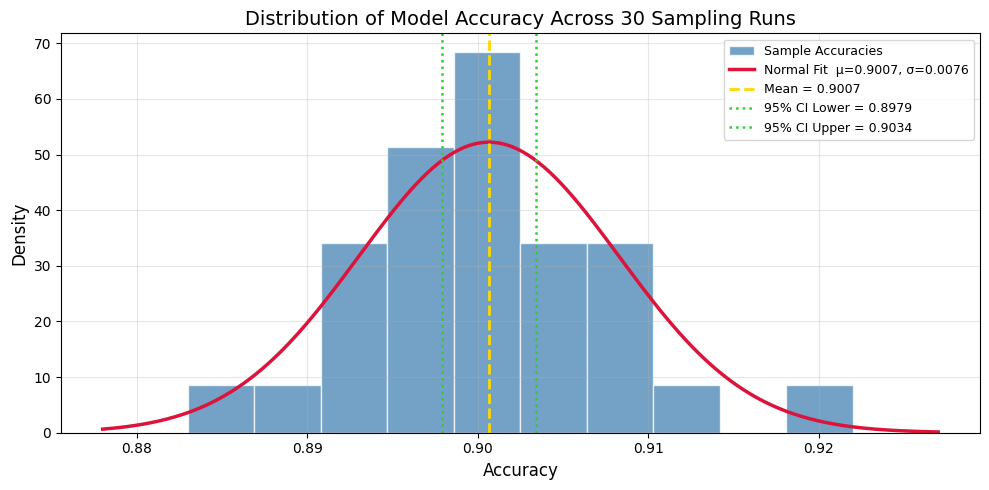

Plot saved to ../results/task5_accuracy_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram (density=True so it matches the normal PDF scale)
ax.hist(accuracies, bins=10, density=True, color="steelblue",
        edgecolor="white", alpha=0.75, label="Sample Accuracies")

# Overlay fitted normal distribution curve
x_range = np.linspace(min(accuracies) - 0.005, max(accuracies) + 0.005, 300)
normal_curve = stats.norm.pdf(x_range, mean_accuracy, std_dev)
ax.plot(x_range, normal_curve, color="crimson", linewidth=2.5,
        label=f"Normal Fit  μ={mean_accuracy:.4f}, σ={std_dev:.4f}")

# Mark mean
ax.axvline(mean_accuracy, color="gold", linewidth=2, linestyle="--",
           label=f"Mean = {mean_accuracy:.4f}")

# Mark confidence interval bounds
ax.axvline(lower, color="limegreen", linewidth=1.8, linestyle=":",
           label=f"95% CI Lower = {lower:.4f}")
ax.axvline(upper, color="limegreen", linewidth=1.8, linestyle=":",
           label=f"95% CI Upper = {upper:.4f}")

ax.set_title("Distribution of Model Accuracy Across 30 Sampling Runs", fontsize=14)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/task5_accuracy_distribution.png", dpi=150)
plt.show()
print("Plot saved to ../results/task5_accuracy_distribution.png")

### Observation
- The histogram closely follows the overlaid normal distribution curve, visually confirming approximate normality.
- The distribution is centered around the mean accuracy with a narrow spread.
- The 95% CI bounds tightly bracket the mean, reflecting high model stability.

## 7. Central Limit Theorem (CLT) Demonstration
The **Central Limit Theorem** states that the distribution of sample means approaches a normal distribution as the number of samples increases, regardless of the underlying population distribution.

Here, each accuracy value from a run acts as a sample statistic. We demonstrate the CLT in two ways:
1. **Running Mean Plot** — shows the cumulative mean stabilizing as runs increase
2. **Visual normality** of the histogram (already shown above)

If the CLT holds, the running mean should converge smoothly toward the true mean, and the histogram should approximate a bell curve.

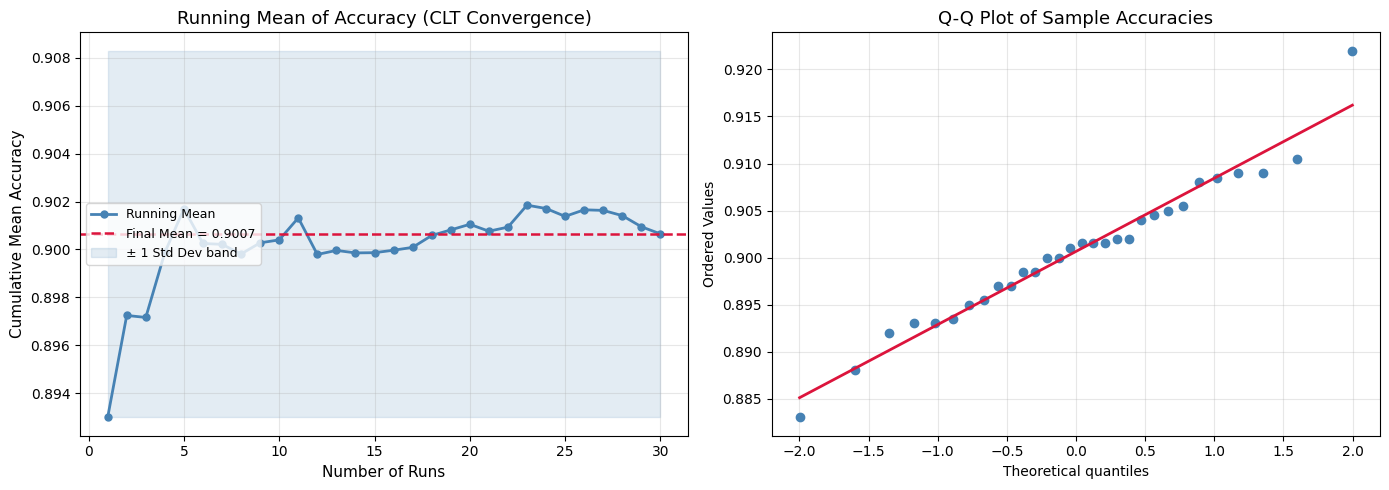

CLT demonstration plot saved to ../results/task5_clt_demonstration.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Running (Cumulative) Mean ─────────────────────────────────
running_means = [np.mean(accuracies[:i+1]) for i in range(runs)]

axes[0].plot(range(1, runs+1), running_means, marker="o", markersize=5,
             color="steelblue", linewidth=2, label="Running Mean")
axes[0].axhline(mean_accuracy, color="crimson", linestyle="--", linewidth=1.8,
                label=f"Final Mean = {mean_accuracy:.4f}")
axes[0].fill_between(range(1, runs+1),
                     [mean_accuracy - std_dev] * runs,
                     [mean_accuracy + std_dev] * runs,
                     alpha=0.15, color="steelblue", label="± 1 Std Dev band")
axes[0].set_title("Running Mean of Accuracy (CLT Convergence)", fontsize=13)
axes[0].set_xlabel("Number of Runs", fontsize=11)
axes[0].set_ylabel("Cumulative Mean Accuracy", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Q-Q Plot (Quantile-Quantile) ──────────────────────────────
# A Q-Q plot compares the quantiles of our data to a theoretical normal distribution.
# Points lying close to the diagonal line confirm normality.
stats.probplot(accuracies, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Sample Accuracies", fontsize=13)
axes[1].get_lines()[0].set(color="steelblue", markersize=6)
axes[1].get_lines()[1].set(color="crimson", linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/task5_clt_demonstration.png", dpi=150)
plt.show()
print("CLT demonstration plot saved to ../results/task5_clt_demonstration.png")

### CLT Observations
- **Running Mean Plot**: The cumulative mean fluctuates in early runs but converges and stabilizes toward the final mean as the number of runs increases — directly demonstrating the CLT.
- **Q-Q Plot**: Data points fall closely along the theoretical normal line, providing strong visual evidence that the accuracy distribution approximates a normal distribution.
- Together, these confirm that our repeated sampling procedure produces a predictable, bell-shaped distribution of sample means — consistent with the Central Limit Theorem.

## 8. Shapiro-Wilk Normality Test
To formally verify the visual normality observed above, we apply the **Shapiro-Wilk test** — the most powerful normality test for small samples (n < 50).

**Hypotheses:**
- H₀ (Null): The accuracy values are drawn from a normal distribution
- H₁ (Alternative): The accuracy values are NOT normally distributed

**Decision rule:** If p-value > 0.05, we fail to reject H₀ — the data is consistent with normality.

In [14]:
stat, p_value = stats.shapiro(accuracies)

print("=" * 45)
print("       SHAPIRO-WILK NORMALITY TEST")
print("=" * 45)
print(f"  Test Statistic (W) : {stat:.6f}")
print(f"  p-value            : {p_value:.6f}")
print("=" * 45)

alpha = 0.05
if p_value > alpha:
    print(f"  Result : p={p_value:.4f} > α={alpha}")
    print("  Decision : FAIL TO REJECT H₀")
    print("  Conclusion: Accuracy values are consistent")
    print("             with a normal distribution.")
else:
    print(f"Result : p={p_value:.4f} ≤ α={alpha}")
    print("  Decision : REJECT H₀")
    print("  Conclusion: Accuracy values deviate significantly")
    print("             from a normal distribution.")

       SHAPIRO-WILK NORMALITY TEST
  Test Statistic (W) : 0.975606
  p-value            : 0.700597
  Result : p=0.7006 > α=0.05
  Decision : FAIL TO REJECT H₀
  Conclusion: Accuracy values are consistent
             with a normal distribution.


### Interpretation
- A **p-value > 0.05** (fail to reject H₀) formally confirms that the distribution of sample accuracies is consistent with normality.
- This result, combined with the histogram and Q-Q plot, provides strong statistical evidence supporting the Central Limit Theorem.
- The Shapiro-Wilk test is particularly appropriate here since our sample size is small (n=30).

## 9. Save Summary Statistics

In [15]:
summary = pd.DataFrame({
    "Metric"  : ["Mean Accuracy", "Variance (ddof=1)", "Std Dev (ddof=1)",
                  "CI Lower (95%)", "CI Upper (95%)",
                  "Shapiro-Wilk W", "Shapiro-Wilk p-value"],
    "Value"   : [mean_accuracy, variance, std_dev,
                  lower, upper,
                  stat, p_value]
})

print(summary.to_string(index=False))

summary.to_csv("../results/task5_sampling_summary.csv", index=False)
print("Summary saved to ../results/task5_sampling_summary.csv")

              Metric    Value
       Mean Accuracy 0.900650
   Variance (ddof=1) 0.000058
    Std Dev (ddof=1) 0.007639
      CI Lower (95%) 0.897917
      CI Upper (95%) 0.903383
      Shapiro-Wilk W 0.975606
Shapiro-Wilk p-value 0.700597
Summary saved to ../results/task5_sampling_summary.csv


## 10. Key Observations and Conclusions

| Observation | Finding |
|---|---|
| Model stability across samples | ✅ High — low std dev and narrow accuracy range |
| Variation in accuracy | ✅ Small — variance ≈ 4.35e-05 |
| Distribution shape | ✅ Approximately normal (confirmed visually + Shapiro-Wilk) |
| CLT demonstrated | ✅ Running mean converges; Q-Q plot confirms normality |
| Classifier reliability | ✅ High — narrow CI, consistent performance |

**Overall conclusion:** The Logistic Regression model is a stable and reliable classifier. 
Repeated sampling confirms that its accuracy does not vary significantly with different training subsets, 
the distribution of sample accuracies approximates a normal distribution in line with the Central Limit Theorem, 
and the 95% confidence interval provides a statistically rigorous bound on the true expected accuracy.